In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/online_shoppers_intention.csv")
df.head()



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.shape


(12330, 18)

In [ ]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(12205, 18)

Data Cleaning: The dataset was first checked for missing values using df.isnull().sum(). No missing values were found in any of the 18 columns, so no imputation or missing value treatment was required. Next, the dataset was checked for duplicate records using df.duplicated().sum(). A total of 125 duplicate rows were identified and removed using df = df.drop_duplicates(). After removing the duplicate records, the final dataset contained 12,205 rows and 18 columns, making it ready for further analysis and model building.

In [ ]:
continuous_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]
numeric_df = df[continuous_cols]
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))
outliers.sum()

,0
Administrative,404
Administrative_Duration,1149
Informational,2631
Informational_Duration,2405
ProductRelated,1007
ProductRelated_Duration,951
BounceRates,1428
ExitRates,1325
PageValues,2730
SpecialDay,1249


In [ ]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df[continuous_cols] = df[continuous_cols].clip(
    lower=lower_limit,
    upper=upper_limit,
    axis=1
)
df.shape

(12205, 18)

In [ ]:
df[continuous_cols].skew().sort_values(ascending=False)

,0
Administrative,1.303703
BounceRates,1.234544
Administrative_Duration,1.234182
ProductRelated_Duration,1.156859
ExitRates,1.119473
ProductRelated,1.102964
Informational,0.000000
Informational_Duration,0.000000
PageValues,0.000000
SpecialDay,0.000000


In [ ]:
skewed_cols = [
    'Administrative',
    'Administrative_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates'
]
df[skewed_cols] = np.log1p(df[skewed_cols])
df[skewed_cols].skew().sort_values(ascending=False)

,0
BounceRates,1.223251
ExitRates,1.082895
Administrative,0.483242
Administrative_Duration,0.152065
ProductRelated,-0.334007
ProductRelated_Duration,-1.582211


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  float64
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  float64
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

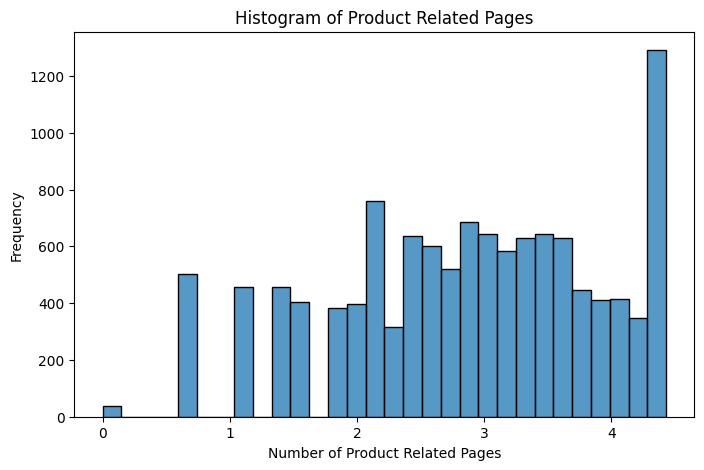

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='ProductRelated',
    bins=30
)

plt.title("Histogram of Product Related Pages")
plt.xlabel("Number of Product Related Pages")
plt.ylabel("Frequency")

plt.show()

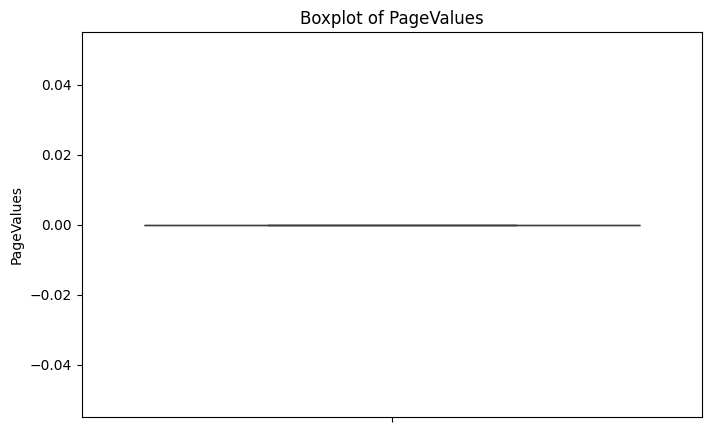

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['PageValues'])

plt.title("Boxplot of PageValues")
plt.ylabel("PageValues")

plt.show()

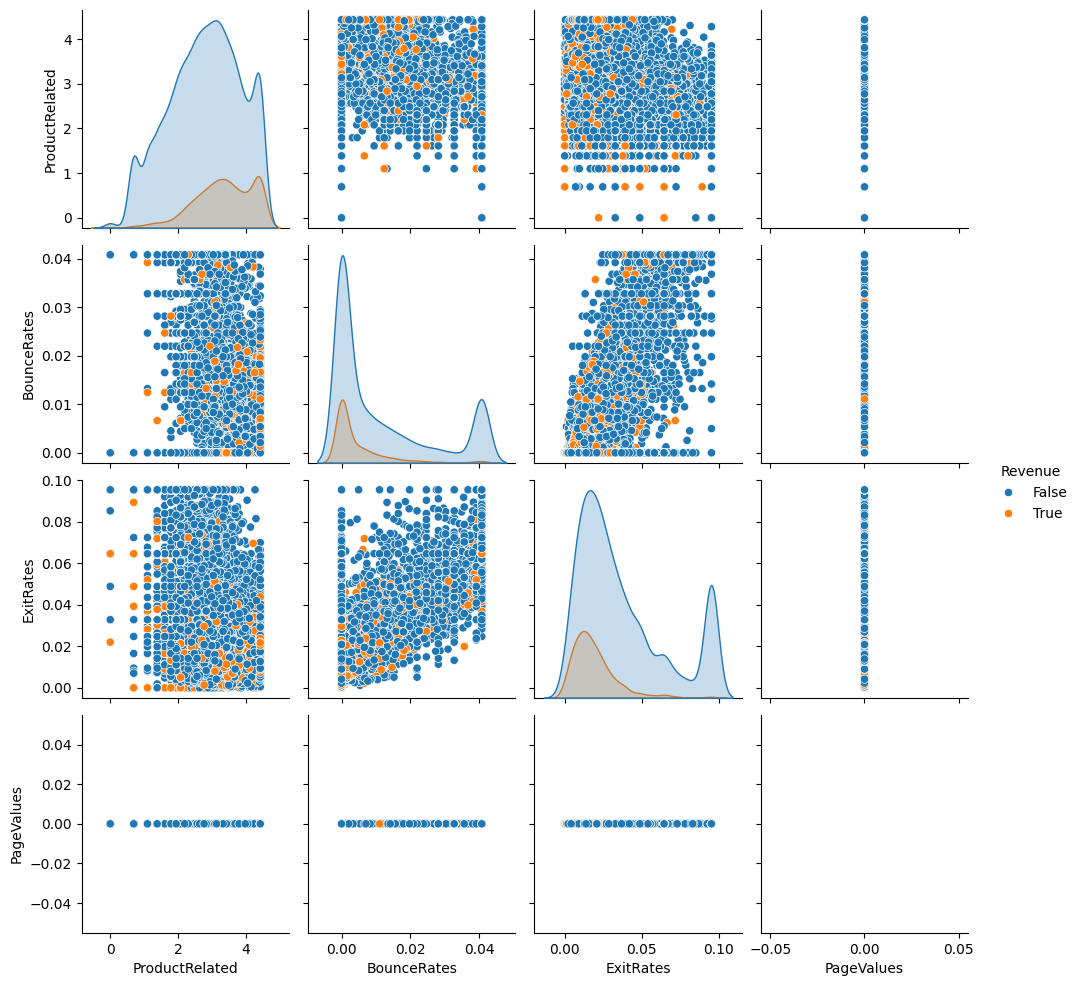

In [ ]:
selected_cols = [
    'ProductRelated',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'Revenue'
]

sns.pairplot(
    df[selected_cols],
    hue='Revenue'
)

plt.show()

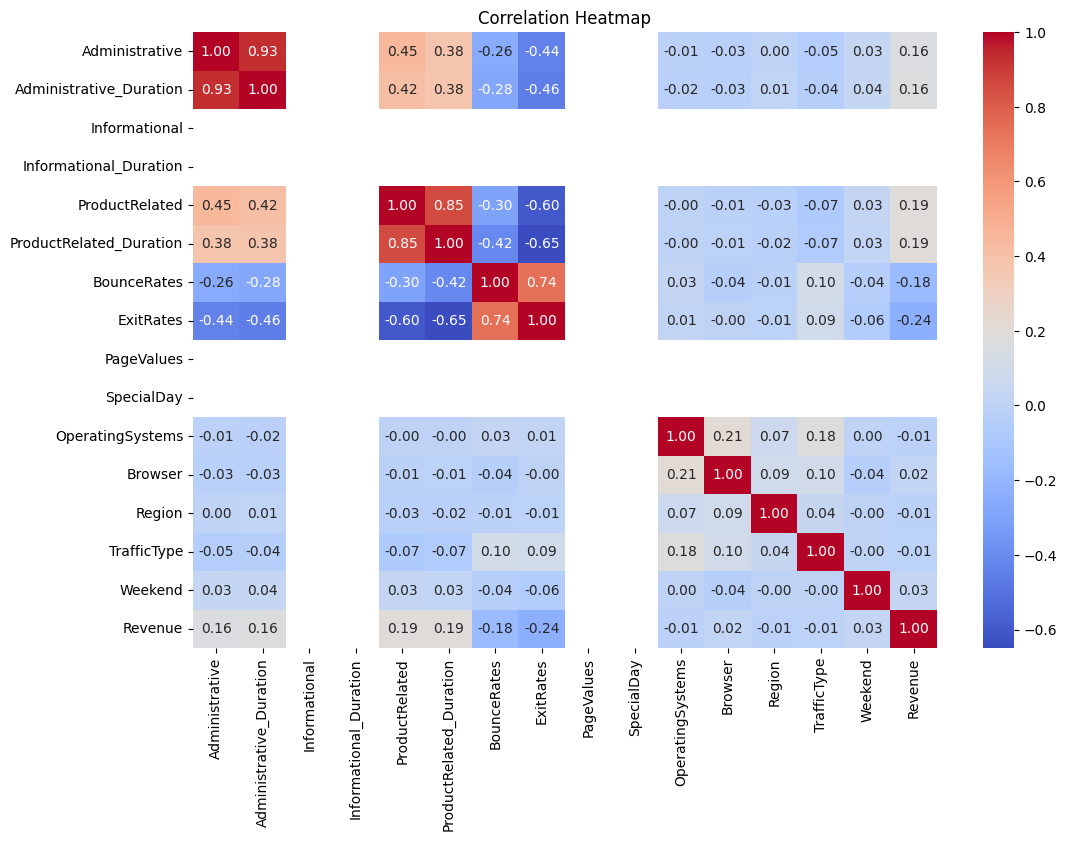

In [ ]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

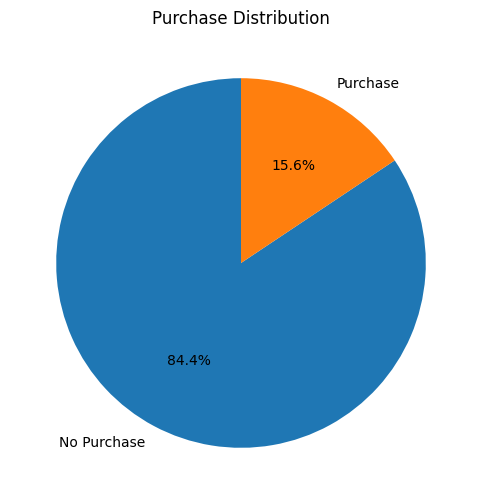

In [ ]:
plt.figure(figsize=(6,6))

df['Revenue'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No Purchase', 'Purchase'],
    startangle=90
)

plt.title("Purchase Distribution")
plt.ylabel("")

plt.show()

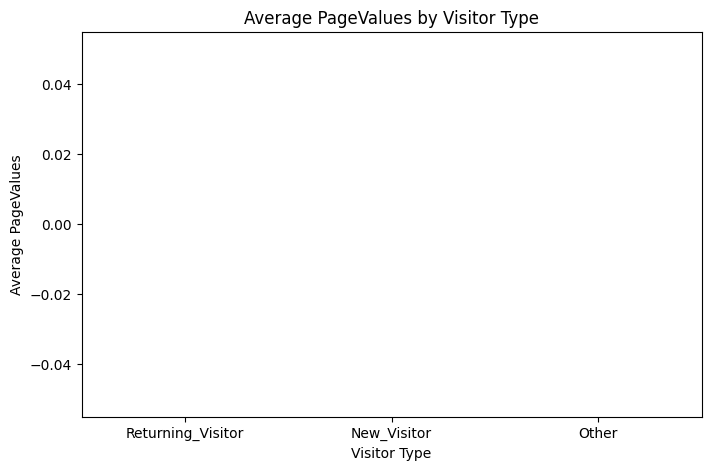

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='VisitorType',
    y='PageValues'
)

plt.title("Average PageValues by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Average PageValues")

plt.show()

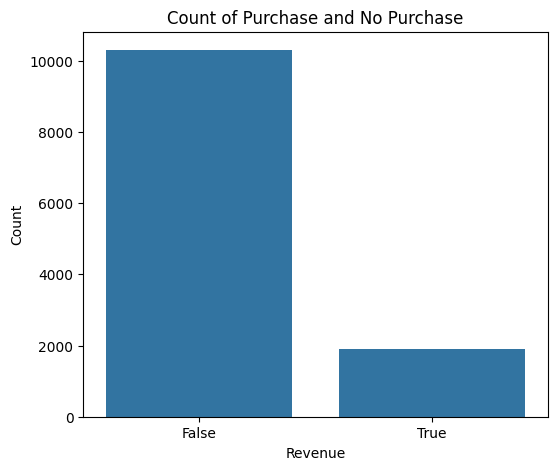

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Revenue'
)

plt.title("Count of Purchase and No Purchase")
plt.xlabel("Revenue")
plt.ylabel("Count")

plt.show()

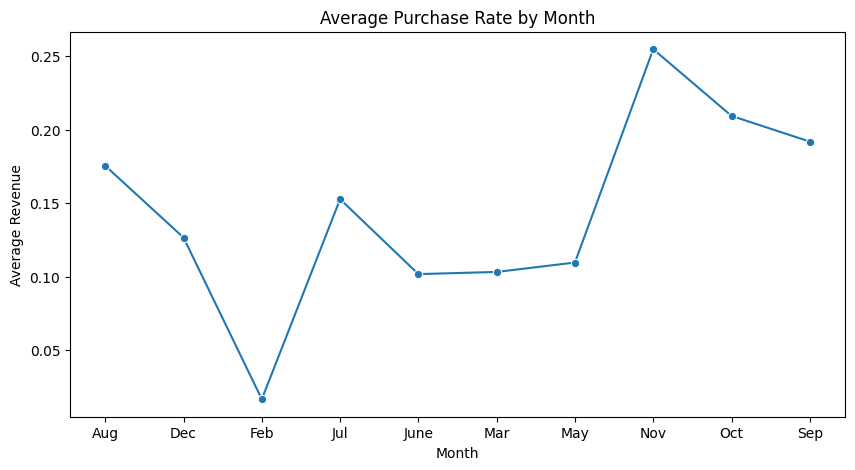

In [ ]:
plt.figure(figsize=(10,5))

monthly_revenue = df.groupby('Month')['Revenue'].mean().reset_index()

sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='Revenue',
    marker='o'
)

plt.title("Average Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.show()

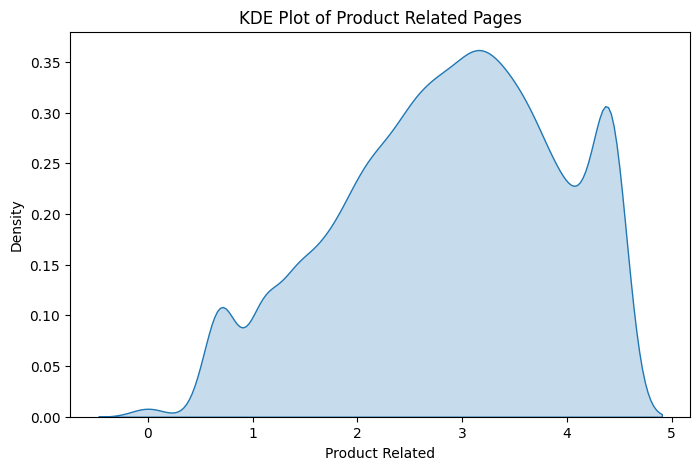

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='ProductRelated',
    fill=True
)

plt.title("KDE Plot of Product Related Pages")
plt.xlabel("Product Related")
plt.ylabel("Density")

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Weekend'] = le.fit_transform(df['Weekend'])

df['Revenue'] = le.fit_transform(df['Revenue'])

df[['Weekend','Revenue']].head()

,Weekend,Revenue
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Month','VisitorType'],
    drop_first=True,
    dtype=int
)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,0,0.0,0.693147,0.000000,0.040822,0.095289,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0.0,0.0,0,0.0,1.098612,4.174387,0.000000,0.095289,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0.0,0.0,0,0.0,0.693147,0.000000,0.040822,0.095289,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0.0,0.0,0,0.0,1.098612,1.299283,0.040822,0.095289,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0.0,0.0,0,0.0,2.397895,6.443336,0.019803,0.048790,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12205 non-null  float64
 1   Administrative_Duration        12205 non-null  float64
 2   Informational                  12205 non-null  int64  
 3   Informational_Duration         12205 non-null  float64
 4   ProductRelated                 12205 non-null  float64
 5   ProductRelated_Duration        12205 non-null  float64
 6   BounceRates                    12205 non-null  float64
 7   ExitRates                      12205 non-null  float64
 8   PageValues                     12205 non-null  float64
 9   SpecialDay                     12205 non-null  float64
 10  OperatingSystems               12205 non-null  int64  
 11  Browser                        12205 non-null  int64  
 12  Region                         12205 non-null  int6

In [ ]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(score_func=chi2, k='all')
X_new = selector.fit_transform(X, y)
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

feature_scores

,Feature,Score
1,Administrative_Duration,743.228873
0,Administrative,281.622888
5,ProductRelated_Duration,275.462506
21,Month_Nov,219.512233
4,ProductRelated,169.596765
20,Month_May,55.016024
19,Month_Mar,39.769196
16,Month_Feb,26.803928
25,VisitorType_Returning_Visitor,18.764598
7,ExitRates,15.543110


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,ExitRates,0.164014
5,ProductRelated_Duration,0.153693
4,ProductRelated,0.115309
1,Administrative_Duration,0.090570
6,BounceRates,0.087137
12,Region,0.063708
0,Administrative,0.063615
13,TrafficType,0.063110
11,Browser,0.039500
10,OperatingSystems,0.035146


In [ ]:
X = X.drop(
    columns=[
        'Informational',
        'Informational_Duration',
        'PageValues',
        'SpecialDay'
    ]
)

X.shape

(12205, 22)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
     stratify=y
)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
print(y_train.value_counts())

Revenue
1    8238
0    8238
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (16476, 22)
X_test shape : (2441, 22)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print(pd.Series(dt_pred).value_counts())
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1:", f1_score(y_test, dt_pred))

0    1891
1     550
Name: count, dtype: int64
Accuracy: 0.751741089717329
Precision: 0.2963636363636364
Recall: 0.42670157068062825
F1: 0.3497854077253219


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='linear',
    C=1.0,
    probability=True
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


Accuracy: 0.751741089717329
Precision: 0.2963636363636364
Recall: 0.42670157068062825
F1 Score: 0.3497854077253219


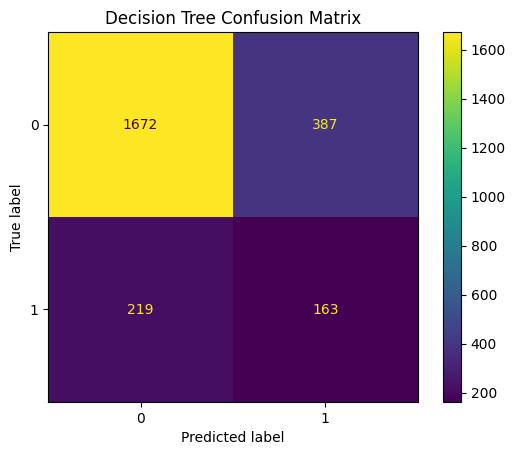

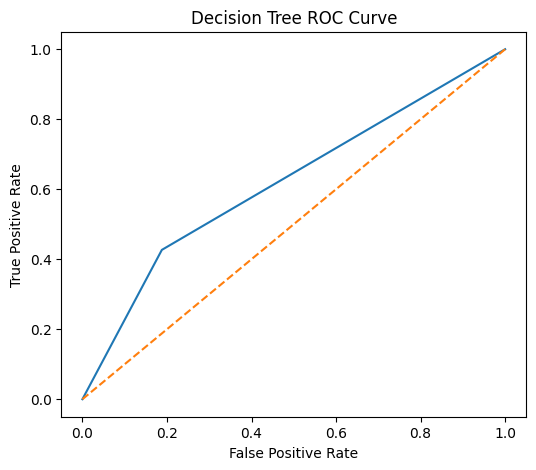

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
#Accuracy
accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, dt_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, dt_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, dt_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

# ROC Curve
y_prob = dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.show()

Accuracy: 0.4924211388775092
Precision: 0.21490352628077178
Recall: 0.8455497382198953
F1 Score: 0.3427055702917772


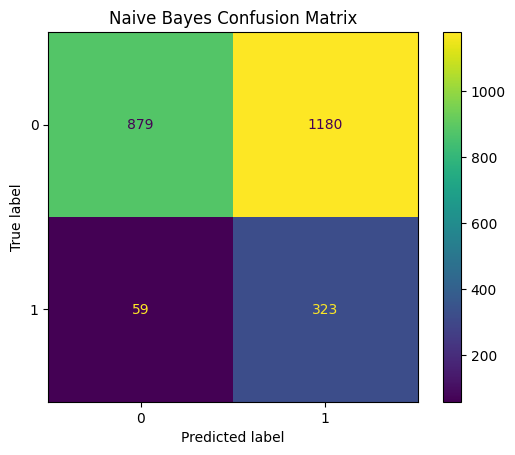

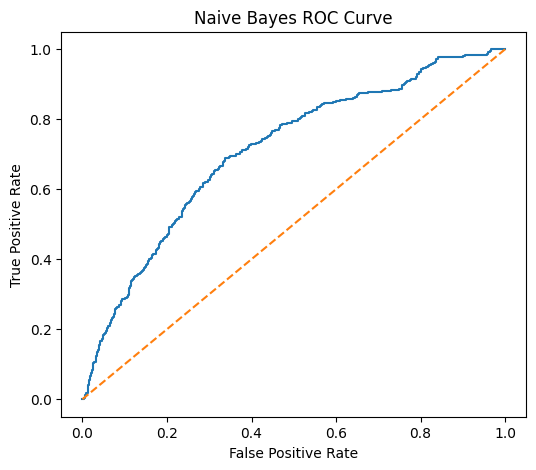

In [ ]:
#Naive Bayes
# Accuracy
accuracy = accuracy_score(y_test, nb_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, nb_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, nb_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, nb_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# ROC Curve
y_prob = nb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.show()

Accuracy: 0.7353543629659975
Precision: 0.30415430267062316
Recall: 0.5366492146596858
F1 Score: 0.38825757575757575


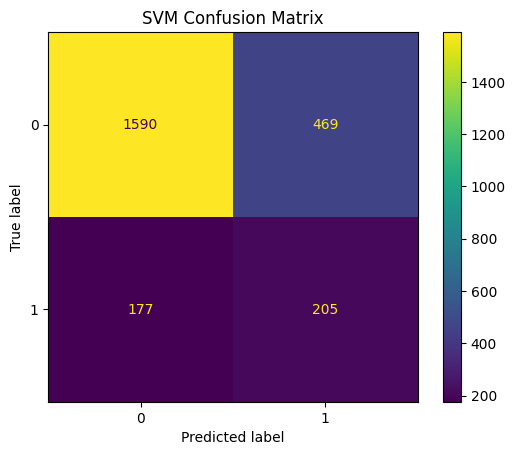

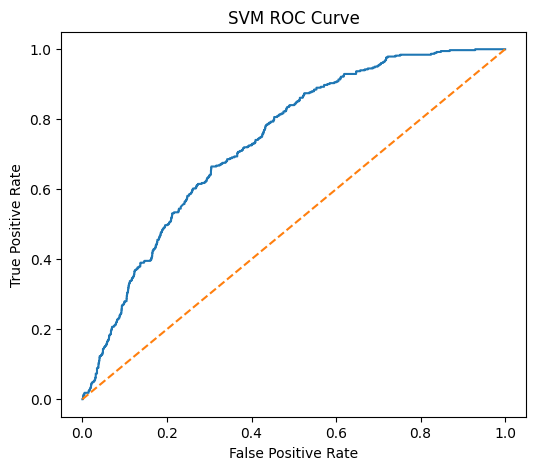

In [ ]:
# SVM

# Accuracy
accuracy = accuracy_score(y_test, svm_pred)
print("Accuracy:", accuracy)
# Precision
precision = precision_score(y_test, svm_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, svm_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, svm_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

# ROC Curve
y_prob = svm.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.show()

Accuracy: 0.7918885702580909
Precision: 0.33507853403141363
Recall: 0.33507853403141363
F1 Score: 0.33507853403141363


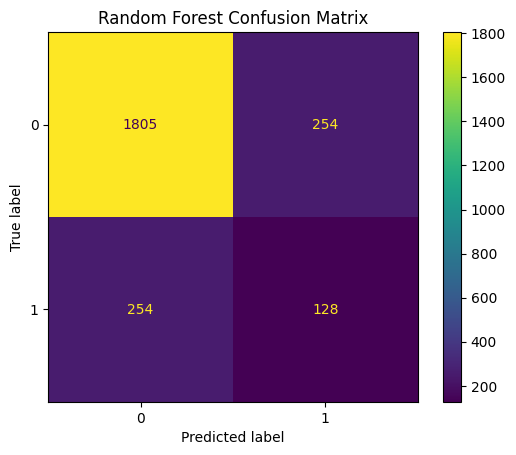

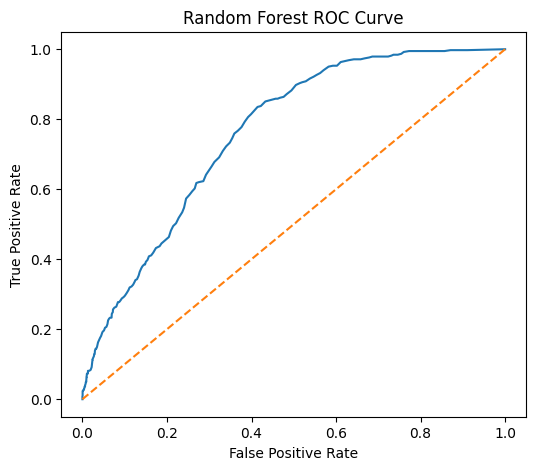

In [ ]:
# Random Forest

# Accuracy
accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, rf_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, rf_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, rf_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# ROC Curve
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.show()

Accuracy: 0.740270380991397
Precision: 0.3136094674556213
Recall: 0.5549738219895288
F1 Score: 0.4007561436672968


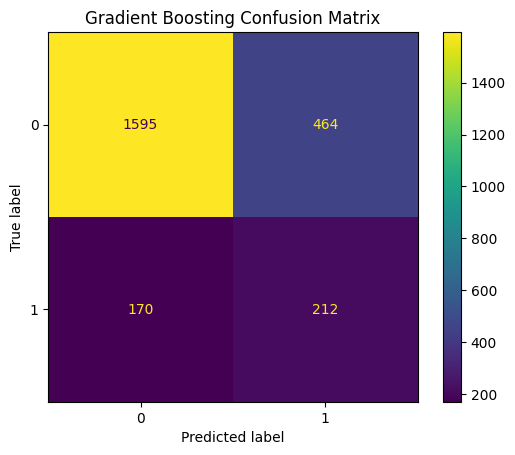

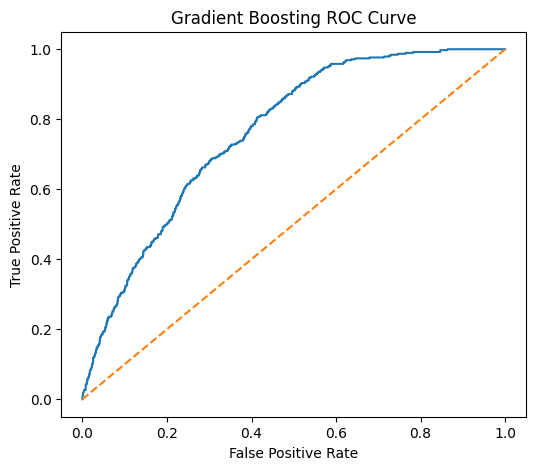

In [ ]:
# Gradient Boosting

# Accuracy
accuracy = accuracy_score(y_test, gb_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, gb_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, gb_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, gb_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# ROC Curve
y_prob = gb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.show()

Gradient Boosting performed the best overall because it achieved the highest F1 Score (0.4008), indicating the best balance between Precision and Recall. Although Random Forest achieved the highest Accuracy (79.19%), its Recall and F1 Score were lower. Since the dataset is imbalanced, the F1 Score provides a more reliable measure of model performance than Accuracy alone.

Naive Bayes performed the worst overall. It achieved the lowest Accuracy (49.24%) and the lowest Precision (21.49%). Although it had the highest Recall (84.55%), it produced many false positive predictions, resulting in poor overall performance.

Best Parameters: {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 200}
Best Cross Validation Score: 0.8093755397553499
Accuracy: 0.7689471528062269
Precision: 0.33454545454545453
Recall: 0.4816753926701571
F1 Score: 0.3948497854077253


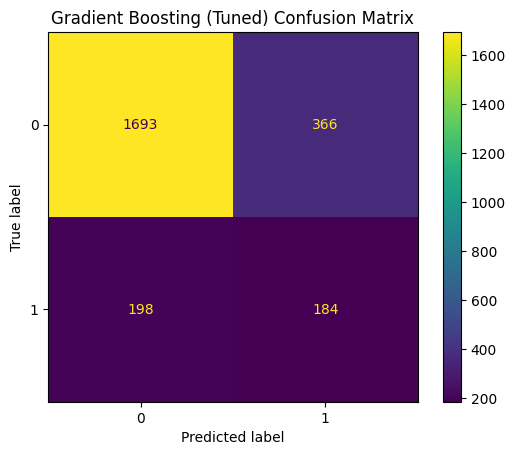

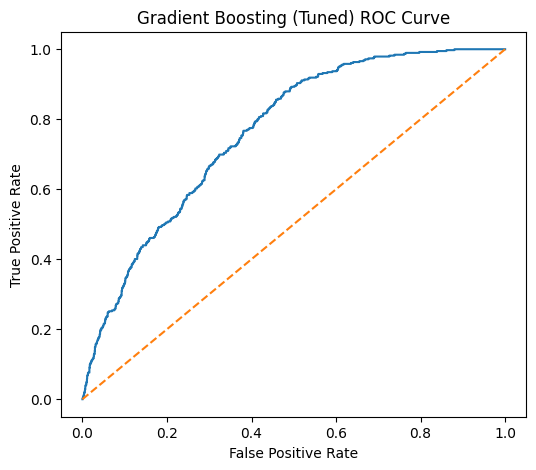

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
# Pipeline
pipe = Pipeline([
    ('gb', GradientBoostingClassifier(random_state=42))
])

# Hyperparameter Grid
param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.1],
    'gb__max_depth': [3]
}

# Grid Search
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

# Train
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# Best Model
best_model = grid.best_estimator_

# Prediction
best_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, best_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, best_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, best_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, best_pred)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Gradient Boosting (Tuned) Confusion Matrix")
plt.show()

# ROC Curve
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting (Tuned) ROC Curve")
plt.show()

Hyperparameter tuning was performed using a Pipeline and GridSearchCV. The best parameters obtained were learning_rate = 0.1, max_depth = 3, and n_estimators = 200. After tuning, the model achieved an Accuracy of 76.89%, Precision of 33.45%, Recall of 48.17%, and F1 Score of 39.48%. The tuned model showed an improvement in Accuracy and Precision compared to the default model.